Here, we apply normalization/dimensionality reduction/batch correections to the counts matrix:

In [18]:
import time
import os

import numpy as np
import pandas as pd

from scipy import stats
from sklearn.decomposition import PCA

import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sclembas_path = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas_path))
from scLEMBAS import io
from scLEMBAS import preprocess as pp
import scLEMBAS.utilities as utils


In [19]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

In [20]:
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'
seed = 888

Load the raw counts matrix (already filtered for low QC cells):

## Covariate Associations

Use the first n_pcs to understand which covariates are most associated with PC variance:

In [21]:
adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_normalized_counts.h5ad'))

In [22]:
adata.shape

(734650, 16227)

### Cell Cycle Deep Dive

Looks like drug is not a particularly strong source of variance. We will correct for these various other variance sources to capture those that we care about. First, let's look at the relationship between "phase", "G2M_score", and "S_score" since these are all indicators of cell cycle. If they're all closely associated, we probably only need to correct for one.

Let's use a PC component that captures all 3 metrics:

In [23]:
phase_dummies = pd.get_dummies(adata.obs['phase'], prefix='phase').astype(int)
X = pd.concat([adata.obs[['S_score', 'G2M_score']], phase_dummies], axis=1)

pca_mod = PCA(n_components=1, random_state = seed)
pca_mod.fit(X) # fit to all 3 metrics

var_explained_pc1 = pca_mod.explained_variance_ratio_[0]
print(f"Variance explained by PC1 of aggregated cell cycle metrics: {var_explained_pc1:.3%}")

cell_cycle_pc1 = pca_mod.transform(X)
adata.obs.loc[X.index, 'cell_cycle_PC1'] = cell_cycle_pc1[:, 0]

Variance explained by PC1 of aggregated cell cycle metrics: 70.677%


Looks like the PC well accounts for all 3 cell cycle metrics, atleast linearly. So, we will use this as our cell cycle covariate.

## Covariate correction

In [24]:
# adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_normalized_counts.h5ad'))
# adata.obs.loc[X.index, 'cell_cycle_PC1'] = cell_cycle_pc1[:, 0]


Nonlinear:

In [25]:
import scvi
from scipy import sparse
from lightning.pytorch.loggers import CSVLogger
from tqdm import trange

# from lightning.pytorch.strategies import DDPStrategy

scvi.settings.seed = seed
scvi._settings.ScviConfig.dl_num_workers = n_cores

/nobackup/users/hmbaghda/Software/miniforge3/envs/scvi-gpuv2/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scvi-gpuv2/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
[rank: 0] Seed set to 888


Initialize and train the model:

In [26]:
# scvi requires raw counts
adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_filtered_counts.h5ad'))
adata.obs.loc[:, 'cell_cycle_PC1'] = cell_cycle_pc1[:, 0]

scvi.model.SCVI.setup_anndata(
    adata,
    layer = None, 
    categorical_covariate_keys=['plate'],
    continuous_covariate_keys=['pcnt_mito', 'cell_cycle_PC1'],
)
# scvi_mod = scvi.model.SCVI(adata, n_layers=2, n_latent=30, gene_likelihood="nb")

# logger = CSVLogger(
#     save_dir=os.path.join(data_path, 'interim'),
#     version = 'overwrite',
#     name=author + '_scvi_mod')

# n_gpus = 1
# if n_gpus <= 1 or n_gpus is None:
#     scvi_mod.train(
#         max_epochs = 400, 
#         accelerator = 'gpu', 
#         devices = 1,  
#         early_stopping = True, 
#         early_stopping_patience = 15, 
#         early_stopping_monitor = 'reconstruction_loss_validation', # rather than elbo
#         batch_size = 4098, 
#         plan_kwargs={'lr': 1e-3, # default 1e-3 did not decrease loss        
#                      'reduce_lr_on_plateau': True,
#                      'lr_scheduler_metric': 'reconstruction_loss_validation', # rather than elbo
#                      'lr_patience': 8,
#                      'lr_factor': 0.6, 
#                      'max_kl_weight': 0.5, # default of 1 makes model focus just on KL
#                     },
#         logger = logger,
#     )
# else:
#     scvi_mod.train(
#         max_epochs = 400, 
#         accelerator = 'gpu', 
#         devices = n_gpus,  
#         early_stopping = True, 
#         early_stopping_patience = 15, 
#         early_stopping_monitor = 'reconstruction_loss_validation', # rather than elbo
#         batch_size = 4098, 
#         plan_kwargs={'lr': 1e-3, # default 1e-3 did not decrease loss        
#                      'reduce_lr_on_plateau': True,
#                      'lr_scheduler_metric': 'reconstruction_loss_validation', # rather than elbo
#                      'lr_patience': 8,
#                      'lr_factor': 0.6, 
#                      'max_kl_weight': 0.5, # default of 1 makes model focus just on KL
#                     },
#         logger = logger,
#         strategy='ddp_find_unused_parameters_true', 
#     )

# print('Training complete')
# utils.clear_memory()

# print('Save scvi model')
# # qzm, qzv = scvi_mod.get_latent_representation(give_mean=False, return_dist=True)
# # scvi_mod.adata.obsm["X_latent_qzm"] = qzm
# # scvi_mod.adata.obsm["X_latent_qzv"] = qzv

# # scvi_mod.minify_adata()

# scvi_mod.save(os.path.join(data_path, 'processed', author + '_scvi_mod.scvi'), overwrite=True)
# utils.clear_memory()

print('Load scVI model')
scvi_mod = scvi.model.SCVI.load(os.path.join(data_path, 'processed', author + '_scvi_mod.scvi'), adata)


Load scVI model
INFO     File /nobackup/users/hmbaghda/scLEMBAS/analysis/processed/Tahoe100M_scvi_mod.scvi/model.pt already        
         downloaded                                                                                                


/nobackup/users/hmbaghda/Software/miniforge3/envs/scvi-gpuv2/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /nobackup/users/hmbaghda/Software/miniforge3/envs/sc ...


Let's visualize the training results:

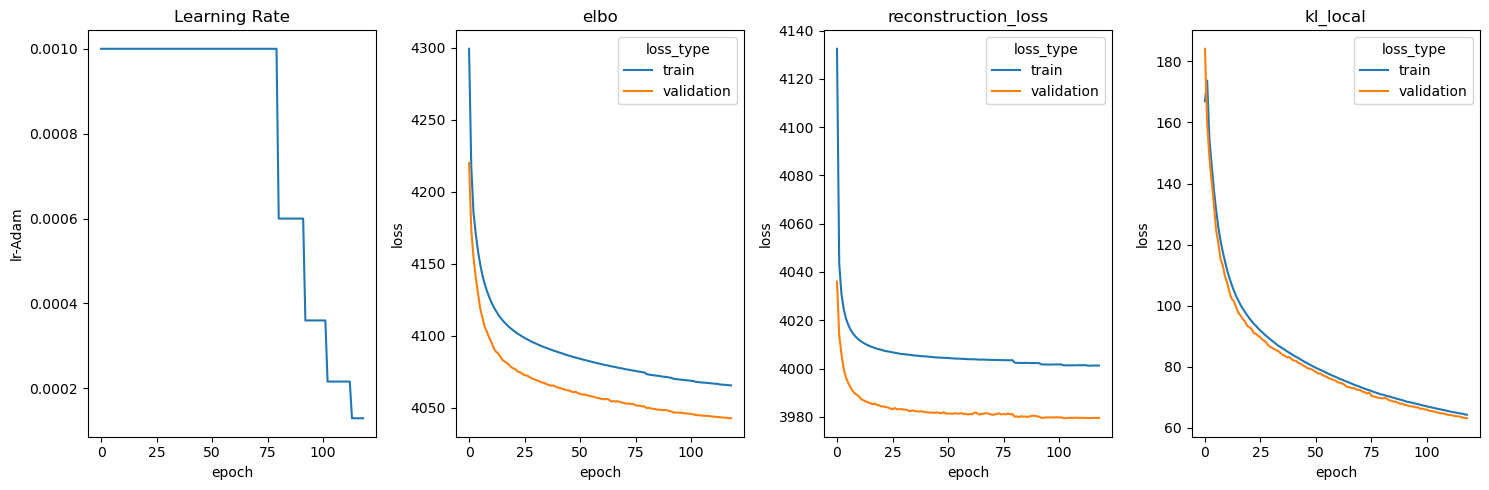

In [27]:
metrics_path = os.path.join(
    data_path, 'interim',
    author + '_scvi_mod',
    'overwrite', # overwrite_2
    'metrics.csv'
)

df = pd.read_csv(metrics_path)
fig, ax = plt.subplots(ncols = 4, figsize = (15, 5))


loss_cols = ['elbo', 'reconstruction_loss']#, 'kl_local']

i = 0
viz_df = df[df['lr-Adam'].notna()][['epoch', 'lr-Adam']]
viz_df.epoch = range(viz_df.shape[0])
sns.lineplot(viz_df, x = 'epoch', y = 'lr-Adam', ax = ax[i])
ax[i].set_title('Learning Rate')


df = df.groupby('epoch').mean()
for i_, loss_type in enumerate(['elbo', 'reconstruction_loss', 'kl_local']):
    i = i+1
    viz_df = df[[loss_type + '_train', loss_type + '_validation']].copy().reset_index()
    viz_df = pd.melt(viz_df, id_vars = 'epoch', var_name = 'loss_type', value_name = 'loss')
    viz_df.loss_type = viz_df.loss_type.apply(lambda x: x.split('_')[-1])
    sns.lineplot(viz_df, x = 'epoch', y = 'loss', hue = 'loss_type', ax = ax[i])
    ax[i].set_title(loss_type)

fig.tight_layout();

# loss_cols = ['elbo', 'reconstruction_loss', 'kl_local']
# df['reconstruction_val_dff'] = df.reconstruction_loss_validation.diff()
# df['kl_val_dff'] = df.kl_local_validation.diff()
# new_cols = ['reconstruction_val_dff', 'kl_val_dff']
# df[[col + '_train' for col in loss_cols] + [col + '_validation' for col in loss_cols] + new_cols].tail(20)


In [28]:
# def get_scvi_normalized_expression(
#     scvi_mod, 
#     n_chunks: int, 
#     library_size: float = 1e6, 
#     batch_size: int = 1024, 
#     sparse_output: bool = False
# ):
#     """
#     Runs scvi_mod.get_normalized_expression in memory-efficient chunks,
#     aggregates results, and assigns to scvi_mod.adata.X as sparse CSR or dense NumPy array.

#     Parameters
#     ----------
#     scvi_mod : scvi.model.SCVI
#         Trained SCVI model.
#     n_chunks : int
#         Number of chunks to break the data into.
#     library_size : float
#         Library size for normalization.
#     batch_size : int
#         Batch size for model prediction.
#     sparse_output : bool
#         If True, aggregate as sparse CSR; else as dense NumPy array.
#     """
#     n_obs = scvi_mod.adata.n_obs
#     n_vars = scvi_mod.adata.n_vars
#     indices = np.arange(n_obs)
#     chunk_size = int(np.ceil(n_obs / n_chunks))
#     chunks = []

#     for i in trange(n_chunks):
#         start = i * chunk_size
#         end = min((i + 1) * chunk_size, n_obs)
#         idx = indices[start:end]
#         norm_expr = scvi_mod.get_normalized_expression(
#             scvi_mod.adata[idx],
#             library_size=library_size,
#             batch_size=batch_size
#         ).astype('float32').values

#         # (Optional) Threshold small values to zero for more sparsity
#         # norm_expr[np.abs(norm_expr) < 1e-3] = 0

#         if sparse_output:
#             chunk = sparse.csr_matrix(norm_expr)
#         else:
#             chunk = norm_expr
#         chunks.append(chunk)
#         utils.clear_memory()

#     # Stack all chunks
#     if sparse_output:
#         scvi_mod.adata.X = sparse.vstack(chunks, format='csr')
#     else:
#         scvi_mod.adata.X = np.vstack(chunks)
    
#     return scvi_mod.adata


# print('Get counts')
# # adata.layers['normalized_counts'] = adata.X.copy()
# # this will replace normalized counts with scvi corrected counts
# adata = get_scvi_normalized_expression(scvi_mod = scvi_mod,  
#                                        n_chunks = 10, 
#                                       library_size = 1e6, 
#                                       batch_size = 1024, 
#                                       sparse_output = False)

# print('Get latent')
# adata.obsm['X_scVI'] = scvi_mod.get_latent_representation(adata)
# # del adata.layers['counts']
# utils.clear_memory()

# print('Save anndata object')
# adata.write_h5ad(os.path.join(data_path, 'interim', author + '_scvi_counts.h5ad'))


In [29]:
#adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_scvi_counts.h5ad'))

In [30]:

# sc.pp.log1p(adata)
# sc.pp.highly_variable_genes(adata, n_top_genes=3000, batch_key=None, flavor = 'seurat')
# sc.tl.pca(
#     data = adata, 
#     zero_center = True, # use cov matrix
#     mask_var = 'highly_variable', # use hvgs
#     random_state = seed)
# adata.write_h5ad(os.path.join(data_path, 'trash.h5ad'))
adata = sc.read_h5ad(os.path.join(data_path, 'trash.h5ad'))

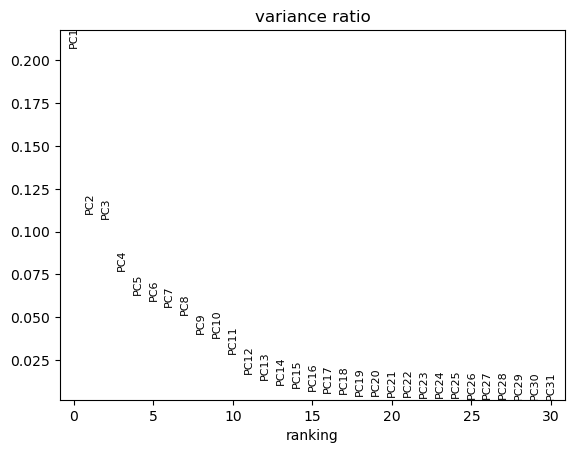

The elbow was automatically identified at PC 12


In [31]:
n_pcs = pp._compute_elbow(adata, curve='convex', direction='decreasing')
adata.uns["pca"]['pca_rank'] = n_pcs

sc.pl.pca_variance_ratio(adata)
print('The elbow was automatically identified at PC {}'.format(n_pcs))

In [32]:
# r2_df_linear = pp.latent_association(
#     adata = adata,
#     covariates = ['cell_line', 'drug', 'plate', 'phase', 'S_score', 'G2M_score', 'pcnt_mito'], 
#     model_type = 'linear', 
#     latent_label = 'pca',
#     n_cores = n_cores, 
#     seed = seed
# )

# r2_df_nl = pp.latent_association(
#     adata = adata,
#     covariates = ['cell_line', 'drug', 'plate', 'phase', 'S_score', 'G2M_score', 'pcnt_mito'], 
#     model_type = 'nonlinear',
#     latent_label = 'pca',
#     n_cores = n_cores, 
#     seed = seed
# )

# r2_df = pd.concat([r2_df_linear, r2_df_nl])
# r2_df.to_csv(os.path.join(data_path, 'processed', author + '_geneexpr_scvi_corrected_pc_associations.csv'))

r2_df = pd.read_csv(os.path.join(data_path, 'processed', author + '_geneexpr_scvi_corrected_pc_associations.csv'), 
                   index_col = 0)

/tmp/ipykernel_1265155/2319586545.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(xlabels, rotation=45)
/tmp/ipykernel_1265155/2319586545.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(xlabels, rotation=45)


''

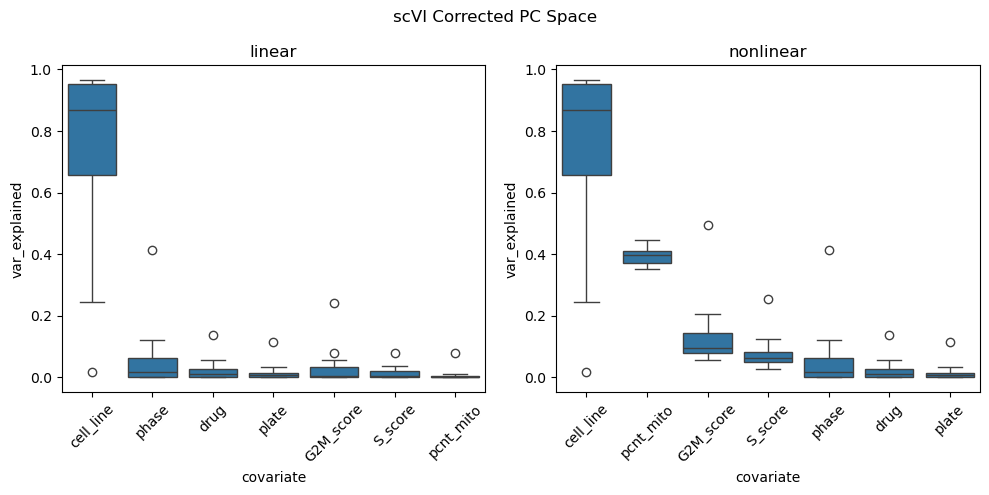

In [33]:
fig, ax = plt.subplots(ncols = 2, figsize = (10, 5))
for i, model_type in enumerate(['linear', 'nonlinear']):
    viz_df = r2_df[r2_df.model_type == model_type]
    viz_df = viz_df.drop(columns = ['PC', 'model_type']).copy()
    
    ranked_covars = viz_df.median(axis = 0).sort_values(ascending = False).index.tolist()
    
    viz_df = pd.melt(viz_df, var_name='covariate', value_name = 'var_explained')
    viz_df.covariate = pd.Categorical(viz_df.covariate, 
                                 categories = ranked_covars, 
                                 ordered=True)
    
    sns.boxplot(data = viz_df, x = 'covariate', y = 'var_explained', ax = ax[i])
    
    ax[i].set_title(model_type)
    
    xlabels = ax[i].get_xticklabels()
    ax[i].set_xticklabels(xlabels, rotation=45)

fig.suptitle('scVI Corrected PC Space')
fig.tight_layout()
;

In [34]:
pd.melt(r2_df.set_index('PC'), id_vars='model_type', var_name='covariate').groupby(['model_type', 'covariate']).median()



value
model_type covariate          
linear     G2M_score  0.005428
           S_score    0.004426
           cell_line  0.867510
           drug       0.010308
           pcnt_mito  0.001595
           phase      0.016174
           plate      0.006557
nonlinear  G2M_score  0.095728
           S_score    0.061875
           cell_line  0.867510
           drug       0.010307
           pcnt_mito  0.397451
           phase      0.016174
           plate      0.006557

In [35]:
# r2_df_linear = pp.latent_association(
#     adata = adata,
#     covariates = ['cell_line', 'drug', 'plate', 'phase', 'S_score', 'G2M_score', 'pcnt_mito'], 
#     model_type = 'linear', 
#     latent_label = 'scVI',
#     n_cores = n_cores, 
#     seed = seed
# )

# r2_df_nl = pp.latent_association(
#     adata = adata,
#     covariates = ['cell_line', 'drug', 'plate', 'phase', 'S_score', 'G2M_score', 'pcnt_mito'], 
#     model_type = 'nonlinear',
#     latent_label = 'scVI',
#     n_cores = n_cores, 
#     seed = seed
# )

# r2_df = pd.concat([r2_df_linear, r2_df_nl])
# r2_df.to_csv(os.path.join(data_path, 'processed', author + '_geneexpr_scvi_corrected_latent_associations.csv'))

r2_df = pd.read_csv(os.path.join(data_path, 'processed', author + '_geneexpr_scvi_corrected_latent_associations.csv'), 
                   index_col = 0)


/tmp/ipykernel_1265155/1427144635.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(xlabels, rotation=45)
/tmp/ipykernel_1265155/1427144635.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(xlabels, rotation=45)


''

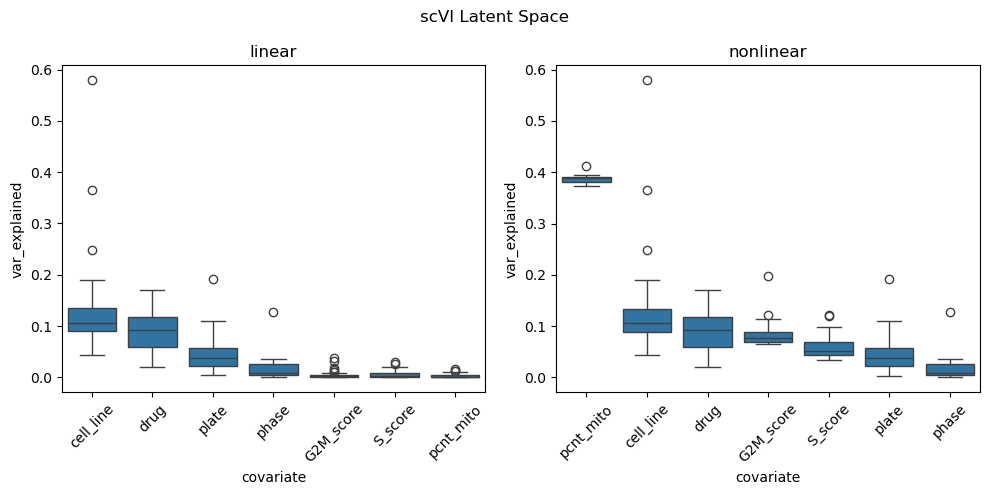

In [36]:
fig, ax = plt.subplots(ncols = 2, figsize = (10, 5))
for i, model_type in enumerate(['linear', 'nonlinear']):
    viz_df = r2_df[r2_df.model_type == model_type]
    viz_df = viz_df.drop(columns = ['PC', 'model_type']).copy()
    
    ranked_covars = viz_df.median(axis = 0).sort_values(ascending = False).index.tolist()
    
    viz_df = pd.melt(viz_df, var_name='covariate', value_name = 'var_explained')
    viz_df.covariate = pd.Categorical(viz_df.covariate, 
                                 categories = ranked_covars, 
                                 ordered=True)
    
    sns.boxplot(data = viz_df, x = 'covariate', y = 'var_explained', ax = ax[i])
    
    ax[i].set_title(model_type)
    
    xlabels = ax[i].get_xticklabels()
    ax[i].set_xticklabels(xlabels, rotation=45)

fig.suptitle('scVI Latent Space')
fig.tight_layout()
;

# PLS-DA

In [9]:
import Tahoe_utils as Tu
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
import umap
from tqdm import trange

In [5]:
adata = sc.read_h5ad(os.path.join(data_path, 'trash.h5ad'))

In [6]:
models, assessment, X_pls = Tu.pls_da(adata,
       n_components = 5,
       control_confounders = ['cell_line'],
          assess = True,
          return_components = True,
          seed = 888, 
          enc_X = None, 
          enc_Y = None)
pls_model = models['pls_model']

In [7]:
assessment

{'n_components': 5,
 'accuracy': 0.12167971142721024,
 'explained_y': 0.028066436335595912}

In [10]:
proj_df = pd.DataFrame(X_pls)
proj_df.columns = ['PLS{}'.format(i+1) for i in range(proj_df.shape[1])]

res = []
for cov_ in ['drug', 'cell_line']:
    cov = adata.obs[cov_].astype(str)
    enc = OneHotEncoder(drop="first", sparse_output=False)
    cov_encoded = enc.fit_transform(cov.values.reshape(-1, 1))

    r2_scores = []
    for pls_idx in trange(proj_df.shape[1]):
        y = proj_df.iloc[:, pls_idx]
        model = LinearRegression().fit(cov_encoded, y)
        r2 = model.score(cov_encoded, y)
        r2_scores.append({"PLS": pls_idx + 1, "R2": r2})

    r2_df = pd.DataFrame(r2_scores)
    r2_df['covariate'] = cov_
    res.append(r2_df)
    
r2_df = pd.concat(res, axis=0, ignore_index=True)


100%|█████████████████████████████████████████████| 5/5 [00:01<00:00,  4.21it/s]


In [11]:
r2_df.groupby('covariate').mean()

,PLS,R2
covariate,,
cell_line,3.0,0.253450
drug,3.0,0.190852


In [12]:
r2_df.groupby('covariate').median()

,PLS,R2
covariate,,
cell_line,3.0,0.217054
drug,3.0,0.184523


Text(0.5, 0, 'Covariate')

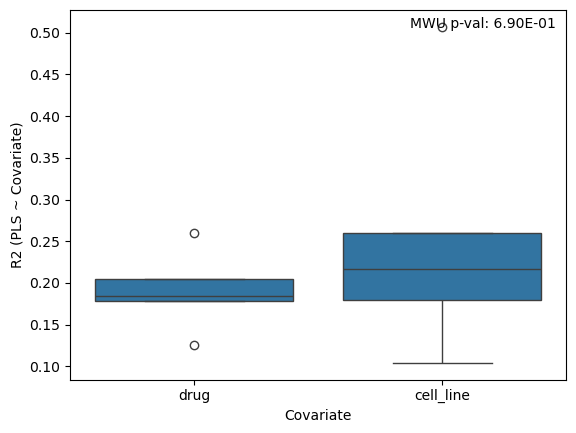

In [13]:
fig, ax = plt.subplots()

pval = stats.mannwhitneyu(r2_df[r2_df.covariate == 'drug'].R2, 
                  r2_df[r2_df.covariate == 'cell_line'].R2).pvalue
sns.boxplot(data = r2_df, x = 'covariate', y = 'R2', ax = ax)

ax.annotate(
    "MWU p-val: {:.2E}".format(pval),
    xy=(0.98, 0.98),
    xycoords="axes fraction",
    ha="right",
    va="top"
)

ax.set_ylabel('R2 (PLS ~ Covariate)')
ax.set_xlabel('Covariate')
# ax.set_title('Top 2 PLS')

In [14]:
proj_df['drug'] = adata.obs.drug.values
proj_df['cell_line'] = adata.obs.cell_line.values
proj_df['condition'] = proj_df.drug.astype(str) + '^' + proj_df.cell_line.astype(str)

''

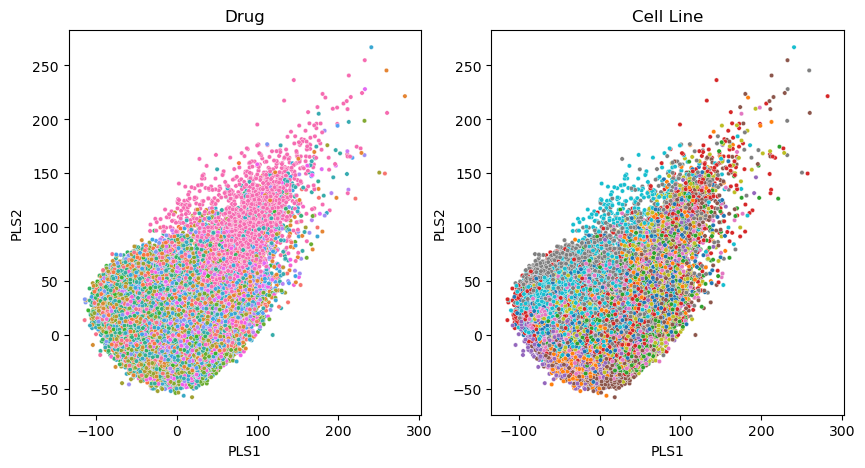

In [15]:
# subset to 20% of the dataset
# n_per_condition = int(np.round(proj_df.drug.value_counts().min() * 0.2))

# # Subsample indices evenly per condition
# sampled_indices = (
#     proj_df.groupby('drug')
#     .sample(n=n_per_condition, random_state=seed)
#     .index
# )

n_per_condition = int(np.round(adata.obs['condition'].value_counts().min() * 0.2))

# Subsample indices evenly per condition
sampled_indices = (
    proj_df.groupby('condition')
    .sample(n=n_per_condition, random_state=seed)
    .index
)

# shuffle
np.random.seed(seed)
sampled_indices=np.random.permutation(sampled_indices)

viz_df = proj_df.loc[sampled_indices, :].copy()

fig, ax = plt.subplots(ncols = 2, figsize = (10, 5))


# DRUG
sns.scatterplot(data = viz_df, x = 'PLS1', y = 'PLS2', hue = 'drug', 
               s = 10, ax = ax[0])
ax[0].legend_.remove()
ax[0].set_title('Drug')

# Cell Line
sns.scatterplot(data = viz_df, x = 'PLS1', y = 'PLS2', hue = 'cell_line', 
               s = 10, ax = ax[1])
ax[1].legend_.remove()
ax[1].set_title('Cell Line')

;

In [16]:
%%time
umap_model = umap.UMAP(n_neighbors=15, 
                    n_components=2,
                    metric='euclidean', 
                    target_metric='categorical', 
                    random_state = seed)
umap_model.fit(X_pls,
               adata.obs['drug'].cat.codes.values)
embedding = umap_model.transform(X_pls)

/nobackup/users/hmbaghda/Software/miniforge3/envs/scvi-gpuv2/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


CPU times: user 1h 14min 6s, sys: 12.2 s, total: 1h 14min 19s
Wall time: 24min 49s


''

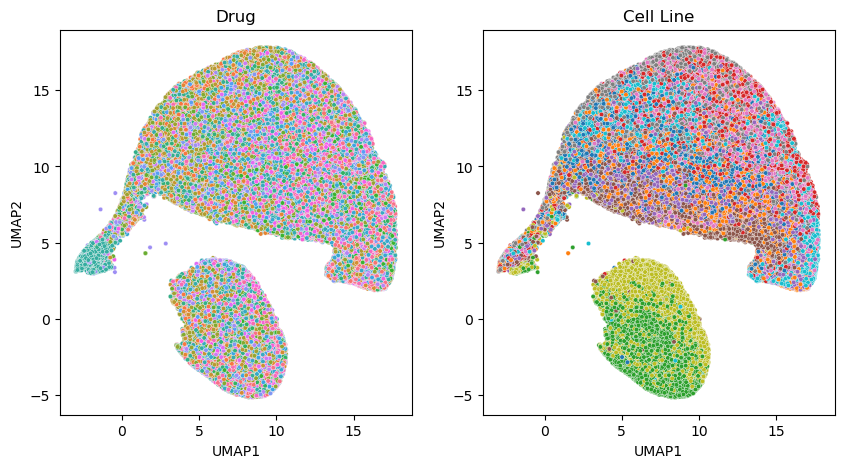

In [17]:
viz_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
viz_df['drug'] = adata.obs.drug.astype(str).values
viz_df['cell_line'] = adata.obs.cell_line.astype(str).values
viz_df = viz_df.loc[sampled_indices, :]

fig, ax = plt.subplots(ncols = 2, figsize = (10, 5))


# DRUG
sns.scatterplot(data = viz_df, x = 'UMAP1', y = 'UMAP2', hue = 'drug', 
               s = 10, ax = ax[0])
ax[0].legend_.remove()
ax[0].set_title('Drug')

# Cell Line
sns.scatterplot(data = viz_df, x = 'UMAP1', y = 'UMAP2', hue = 'cell_line', 
               s = 10, ax = ax[1])
ax[1].legend_.remove()
ax[1].set_title('Cell Line')

;